## hallo 

In [85]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None)

In [86]:
data_transit = "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/transit_stations.csv"

df_transit = pd.read_csv(data_transit)

df_transit

,station_name,line,lat,lon,year_opened,to_brandenburg_gate_km
0,Warschauer Straße,U1,52.5057,13.4495,1902,5.00
1,Schlesisches Tor,U1,52.5012,13.4423,1902,4.68
2,Görlitzer Bahnhof,U1,52.4986,13.4286,1902,3.97
3,Kottbusser Tor,U1,52.4994,13.4181,1902,3.32
4,Prinzenstraße,U1,52.5006,13.4097,1902,2.78
...,...,...,...,...,...,...
130,Charlottenburg S,Stadtbahn,52.5060,13.3030,1882,5.18
131,Savignyplatz,Stadtbahn,52.5050,13.3208,1882,4.05
132,Zoologischer Garten S,Stadtbahn,52.5071,13.3320,1882,3.26
133,Tiergarten S,Stadtbahn,52.5145,13.3501,1882,1.88


In [87]:
data_sales = "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/secondary_sales.csv"

df_sales = pd.read_csv(data_sales)

df_sales

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.50
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.30
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.10
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.50
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,altbau_pre_1949,E,seitenflügel,renovierungsbedürftig,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,S049996,2022-09-17,Märkisches Viertel,Reinickendorf,low,52.60271,13.34964,1_room,1,47.1,2,4,1976,post_war_1949_1990,A,hinterhaus,saniert,True,True,False,True,Voltastraße,U8,35,tram_bus,9.79,129000,2737,139270,2956,3.40
49996,S049997,2023-06-18,Frohnau,Reinickendorf,medium,52.62787,13.29939,2_room,2,65.1,4,5,1942,altbau_pre_1949,G,vorderhaus,kernsaniert,False,True,True,True,Alexanderplatz S,Stadtbahn,64,tram_bus,13.49,216000,3312,232875,3577,3.85
49997,S049998,2023-03-12,Siemensstadt,Spandau,low,52.53700,13.24356,2_room,2,56.9,2,5,1982,post_war_1949_1990,C,vorderhaus,saniert,True,False,True,False,Siemensdamm,U7,11,walk,9.36,198000,3478,213628,3756,3.85
49998,S049999,2026-01-02,Malchow,Lichtenberg,low,52.56763,13.47799,3_room,3,84.4,2,5,1949,post_war_1949_1990,F,vorderhaus,renoviert,True,True,True,False,Alexanderplatz S,Stadtbahn,37,tram_bus,8.86,195000,2310,210673,2495,3.10


In [88]:
data_rentals = "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/rentals.csv"

df_rentals = pd.read_csv(data_rentals)

df_rentals['building_era'].count

<bound method Series.count of 0        post_war_1949_1990
1          modern_1990_2010
2          modern_1990_2010
3           altbau_pre_1949
4          modern_1990_2010
                ...        
29995         new_post_2010
29996       altbau_pre_1949
29997    post_war_1949_1990
29998       altbau_pre_1949
29999      modern_1990_2010
Name: building_era, Length: 30000, dtype: object>

In [89]:
data_new= "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/new_construction.csv"

df_new = pd.read_csv(data_new)

df_new.columns


Index(['id', 'date_listed', 'project_id', 'project_name', 'developer',
       'ortsteil', 'bezirk', 'lat', 'lon', 'property_type', 'rooms', 'area_m2',
       'floor', 'total_floors', 'energy_class', 'completion_year',
       'total_project_units', 'possession_status', 'payment_plan', 'has_lift',
       'has_balcony', 'has_parking', 'transit_station', 'transit_line',
       'transit_distance_min', 'to_brandenburg_gate_km', 'price_eur',
       'price_per_m2_eur', 'price_usd', 'price_per_m2_usd',
       'mortgage_rate_at_listing'],
      dtype='object')

In [90]:
data_monthly= "/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/kiez_prices_monthly.csv"

df_monthly= pd.read_csv(data_monthly)

df_monthly

,year_month,ortsteil,bezirk,kiez_premium,secondary_price_per_m2_eur,new_construction_price_per_m2_eur,kaltmiete_per_m2_monthly_eur,secondary_price_per_m2_usd,n_listings_secondary,n_listings_new_construction,n_listings_rental,ecb_main_rate_pct,avg_mortgage_rate_pct
0,2020-01,Mitte (Ort),Mitte,high,7389,9312,20.53,7980,22,48,69,0.00,1.1
1,2020-02,Mitte (Ort),Mitte,high,7585,9571,21.07,8192,64,20,150,0.00,1.1
2,2020-03,Mitte (Ort),Mitte,high,7489,9737,19.24,8088,118,44,153,0.00,1.1
3,2020-04,Mitte (Ort),Mitte,high,7400,9376,19.24,7992,158,22,145,0.00,1.1
4,2020-05,Mitte (Ort),Mitte,high,7386,9112,19.21,7977,73,29,59,0.00,1.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6227,2025-12,Waidmannslust,Reinickendorf,low,4328,5479,12.98,4674,70,25,111,2.75,3.1
6228,2026-01,Waidmannslust,Reinickendorf,low,4432,5603,13.29,4787,30,15,161,2.75,3.1
6229,2026-02,Waidmannslust,Reinickendorf,low,4519,5633,13.55,4881,118,26,204,2.75,3.1
6230,2026-03,Waidmannslust,Reinickendorf,low,4344,5426,13.03,4692,20,16,21,2.75,3.1


## Analysis Sales Outliers & Missing Values

In [91]:
####Import
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr

In [92]:
df_sales.isnull().sum()                

id                          0
date_listed                 0
ortsteil                    0
bezirk                      0
kiez_premium                0
lat                         0
lon                         0
property_type               0
rooms                       0
area_m2                     0
floor                       0
total_floors                0
year_built                  0
building_era                0
energy_class                0
position                    0
condition                   0
has_lift                    0
has_balcony                 0
has_cellar                  0
has_parking                 0
transit_station             0
transit_line                0
transit_distance_min        0
transit_distance_type       0
to_brandenburg_gate_km      0
price_eur                   0
price_per_m2_eur            0
price_usd                   0
price_per_m2_usd            0
mortgage_rate_at_listing    0
dtype: int64

In [93]:
print(f" {df_sales.duplicated().sum()} duplicates")

 0 duplicates


In [94]:
target = 'price_eur' 
round(df_sales[target].describe(),0)

count      50000.0
mean      307538.0
std       248698.0
min        21000.0
25%       141000.0
50%       232000.0
75%       392000.0
max      3330000.0
Name: price_eur, dtype: float64

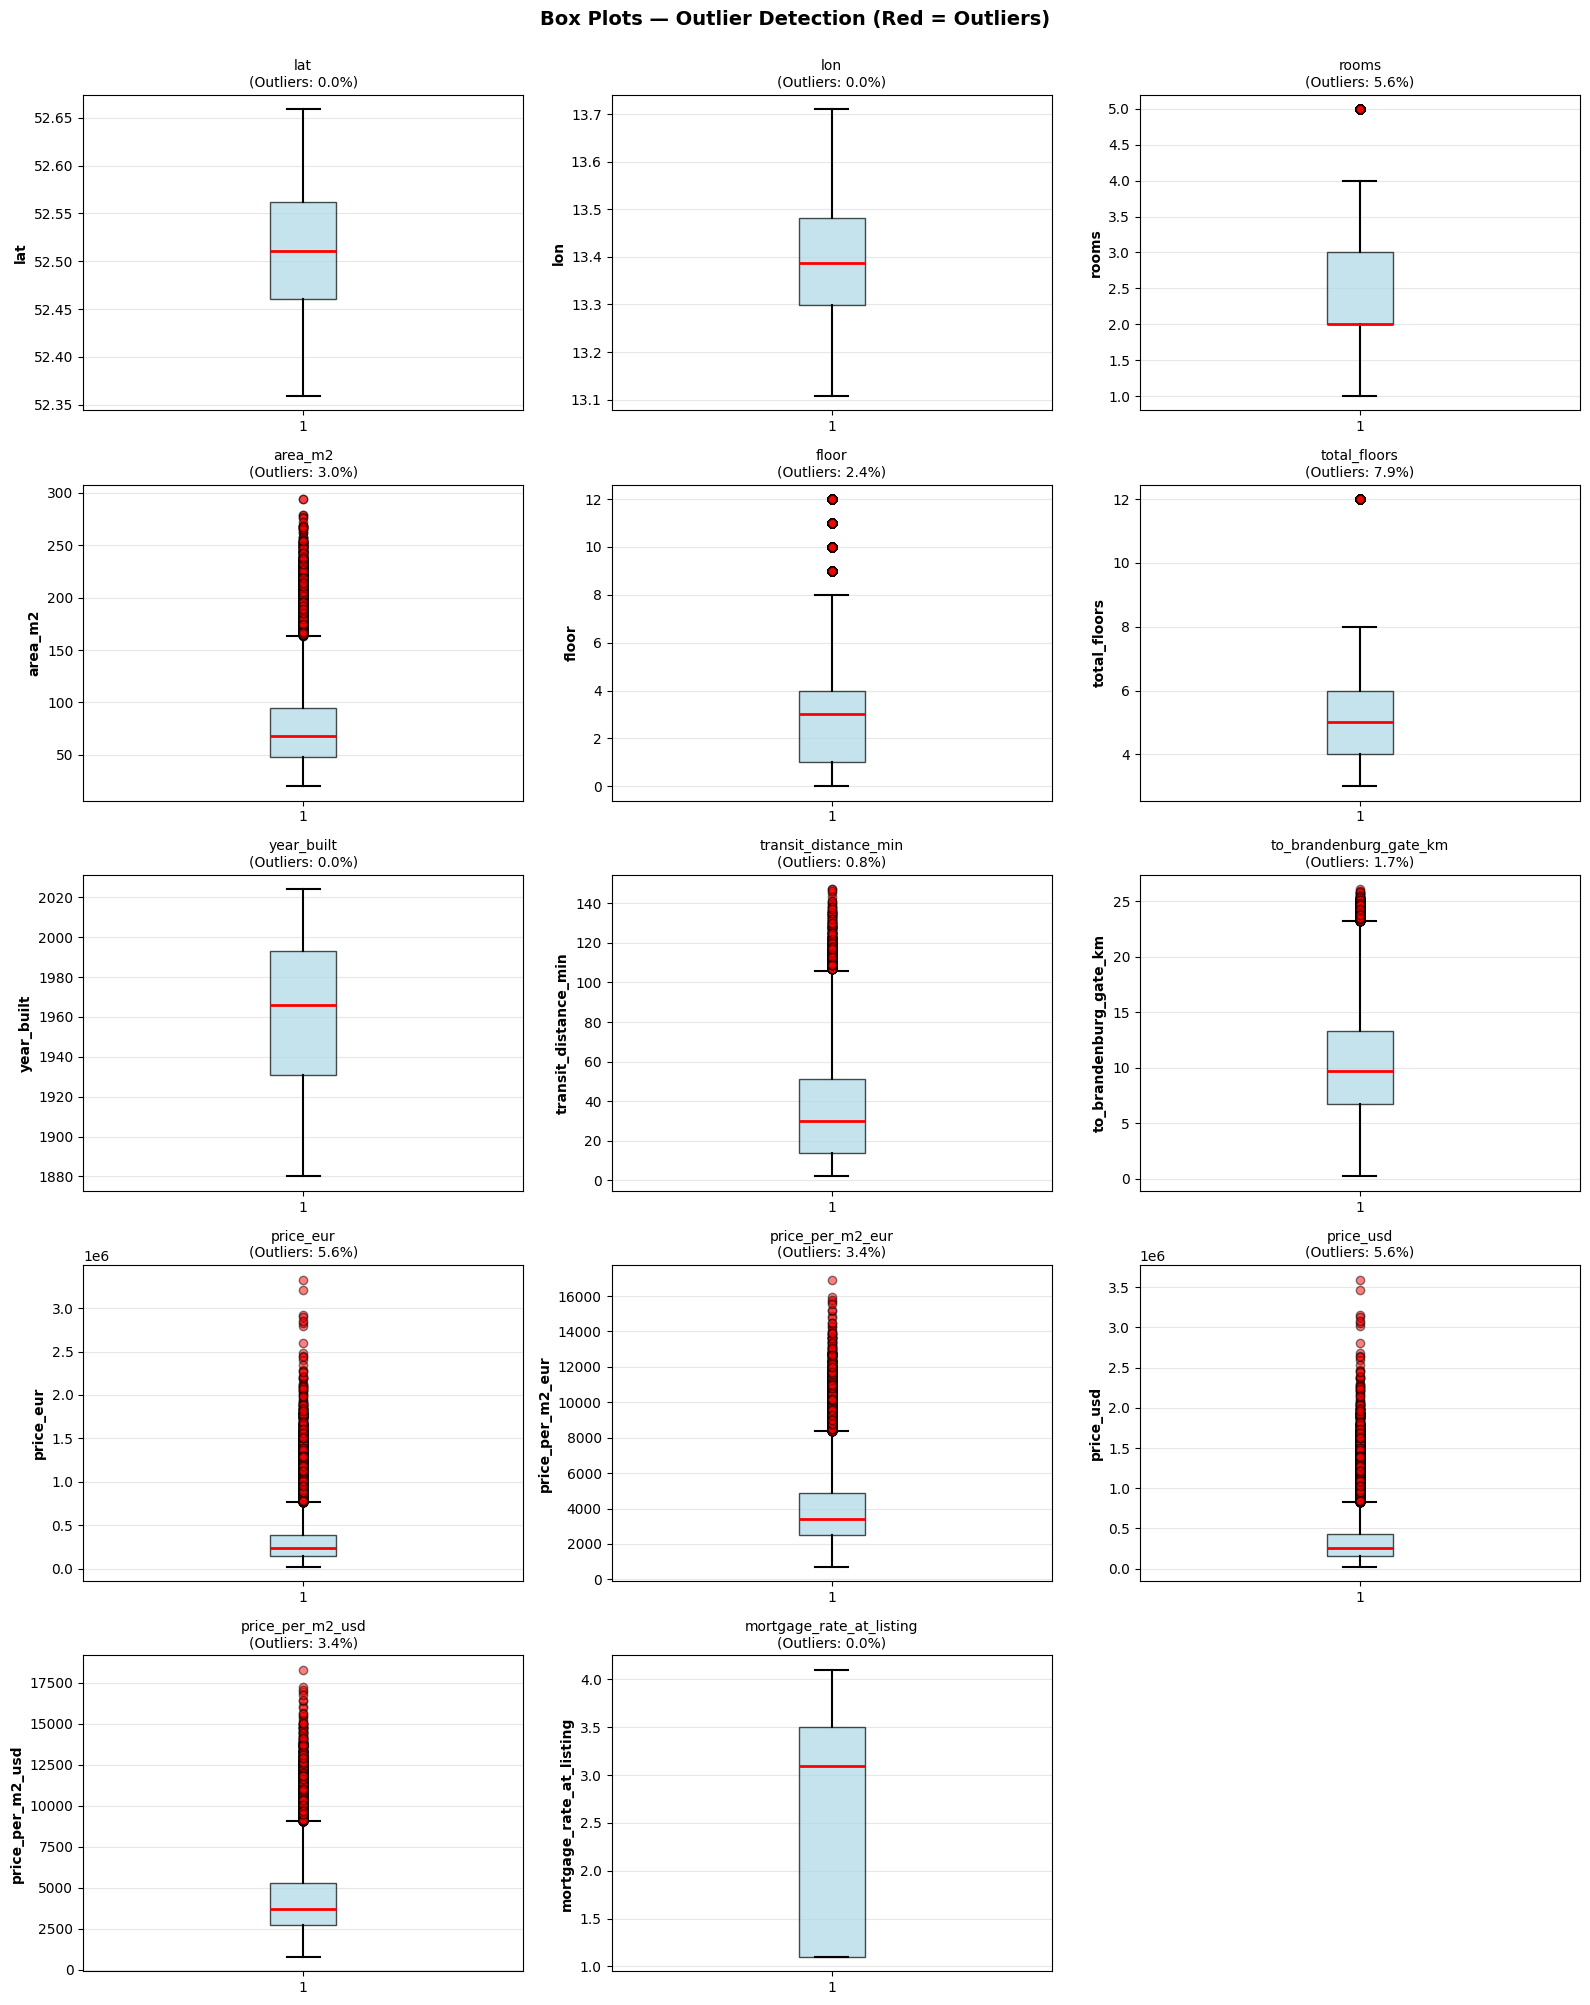

In [95]:
# Create box plots for all numeric columns
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3  # 3 plots per row
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Box plot
    bp = ax.boxplot(df_sales[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightblue', alpha=0.7),
                     whiskerprops=dict(color='black', linewidth=1.5),
                     capprops=dict(color='black', linewidth=1.5),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))
    
    ax.set_ylabel(col, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'{col}\n(Outliers: {outlier_df[outlier_df["Column"]==col]["Outlier_Percent"].values[0]:.1f}%)',
                 fontsize=10)

# Remove extra subplots
for idx in range(n_cols, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Box Plots — Outlier Detection (Red = Outliers)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('02_boxplots_outliers.png', dpi=300, bbox_inches='tight')
plt.show()

✓ Saved: 03_histograms_outlier_bounds.png


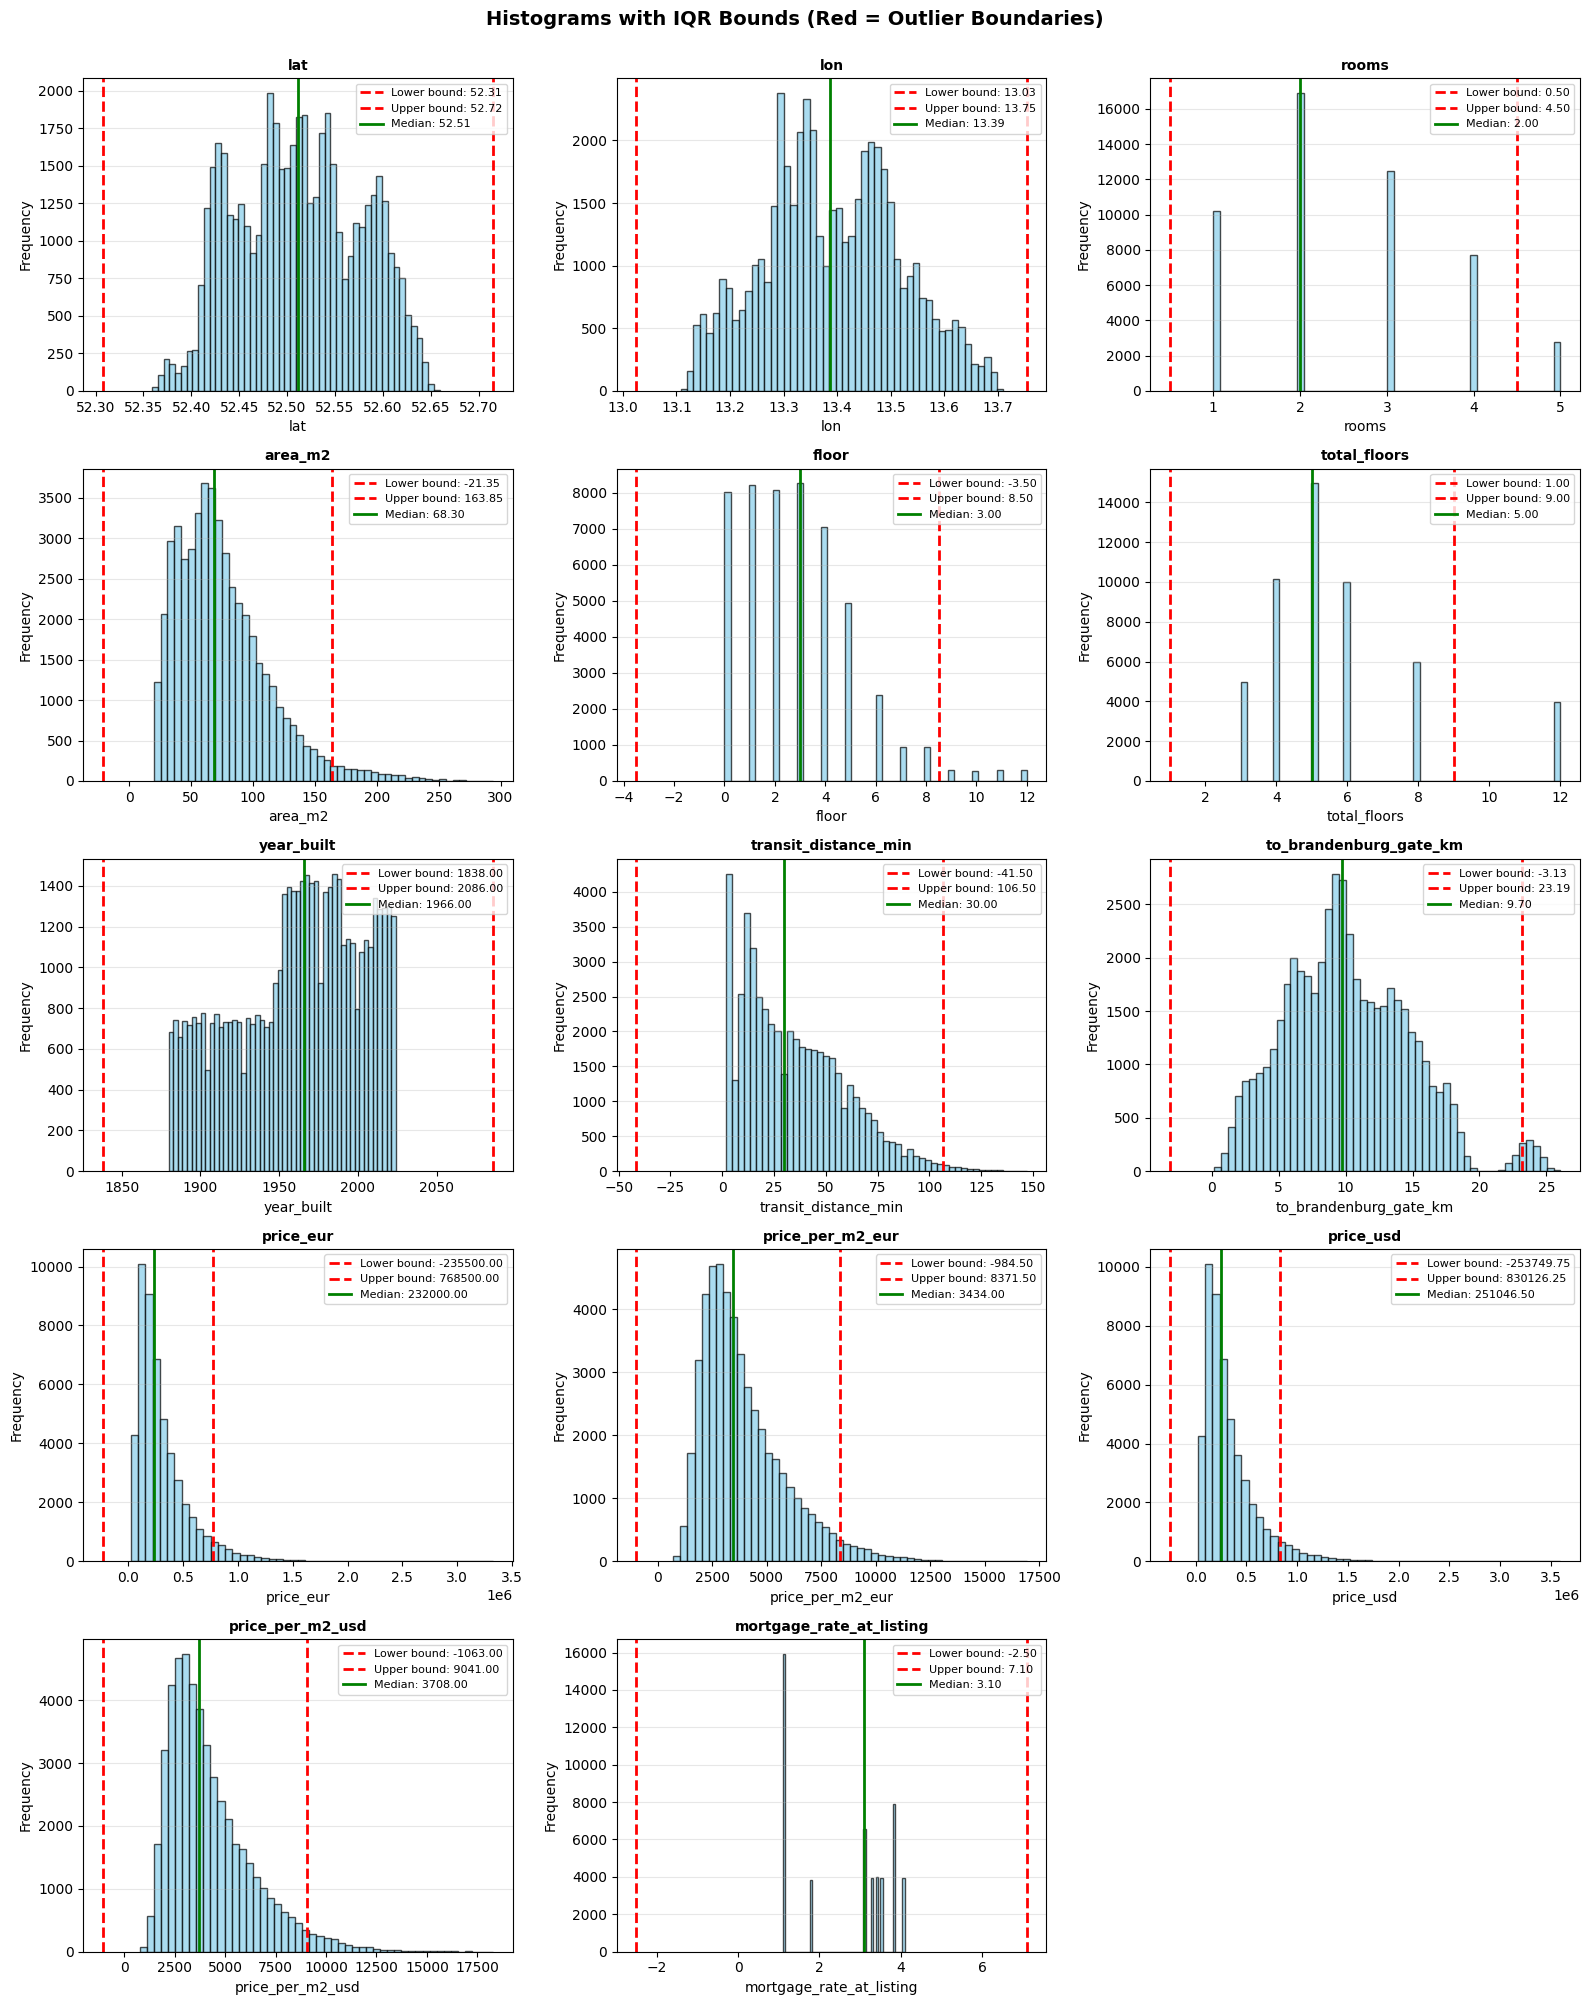

In [96]:
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Get bounds
    Q1 = df_sales[col].quantile(0.25)
    Q3 = df_sales[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Histogram
    ax.hist(df_sales[col].dropna(), bins=50, color='skyblue', edgecolor='black', alpha=0.7)
    
    # Mark bounds
    ax.axvline(lower_bound, color='red', linestyle='--', linewidth=2, label=f'Lower bound: {lower_bound:.2f}')
    ax.axvline(upper_bound, color='red', linestyle='--', linewidth=2, label=f'Upper bound: {upper_bound:.2f}')
    ax.axvline(df_sales[col].median(), color='green', linestyle='-', linewidth=2, label=f'Median: {df_sales[col].median():.2f}')
    
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency', fontsize=10)
    ax.set_title(f'{col}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.3)

# Remove extra subplots
for idx in range(n_cols, len(axes)):
    fig.delaxes(axes[idx])

plt.suptitle('Histograms with IQR Bounds (Red = Outlier Boundaries)', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('03_histograms_outlier_bounds.png', dpi=300, bbox_inches='tight')
print(f"✓ Saved: 03_histograms_outlier_bounds.png")
plt.show()

In [97]:
for col in numeric_cols:
    print(f"\n{col}:")
    print(f"  Count: {df_sales[col].count()}")
    print(f"  Mean: {df_sales[col].mean():.2f}")
    print(f"  Median: {df_sales[col].median():.2f}")
    print(f"  Std: {df_sales[col].std():.2f}")
    print(f"  Min: {df_sales[col].min():.2f}")
    print(f"  Max: {df_sales[col].max():.2f}")
    
    # Skewness & Kurtosis
    skewness = stats.skew(df_sales[col].dropna())
    kurtosis = stats.kurtosis(df_sales[col].dropna())
    print(f"  Skewness: {skewness:.2f}")
    print(f"  Kurtosis: {kurtosis:.2f}")



lat:
  Count: 50000
  Mean: 52.51
  Median: 52.51
  Std: 0.06
  Min: 52.36
  Max: 52.66
  Skewness: 0.05
  Kurtosis: -0.91

lon:
  Count: 50000
  Mean: 13.39
  Median: 13.39
  Std: 0.13
  Min: 13.11
  Max: 13.71
  Skewness: 0.09
  Kurtosis: -0.62

rooms:
  Count: 50000
  Mean: 2.52
  Median: 2.00
  Std: 1.14
  Min: 1.00
  Max: 5.00
  Skewness: 0.41
  Kurtosis: -0.65

area_m2:
  Count: 50000
  Mean: 75.44
  Median: 68.30
  Std: 37.55
  Min: 20.00
  Max: 294.10
  Skewness: 1.25
  Kurtosis: 2.18

floor:
  Count: 50000
  Mean: 2.86
  Median: 3.00
  Std: 2.31
  Min: 0.00
  Max: 12.00
  Skewness: 1.04
  Kurtosis: 1.53

total_floors:
  Count: 50000
  Mean: 5.71
  Median: 5.00
  Std: 2.29
  Min: 3.00
  Max: 12.00
  Skewness: 1.50
  Kurtosis: 1.88

year_built:
  Count: 50000
  Mean: 1961.35
  Median: 1966.00
  Std: 39.78
  Min: 1880.00
  Max: 2024.00
  Skewness: -0.34
  Kurtosis: -0.92

transit_distance_min:
  Count: 50000
  Mean: 34.60
  Median: 30.00
  Std: 24.57
  Min: 2.00
  Max: 147.00
  

## Analysis Sales Relationships

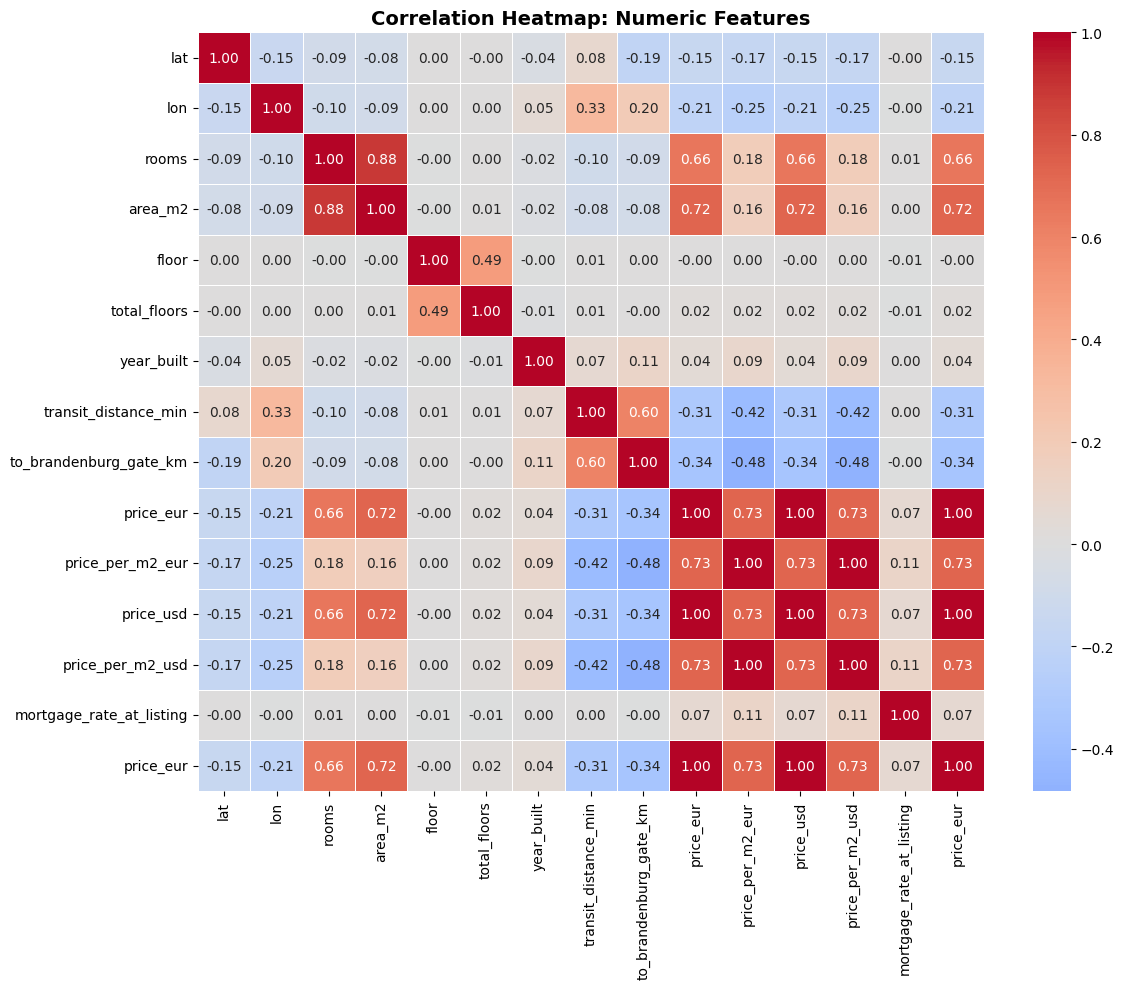

In [98]:
# Select numeric columns + target
corr_matrix = df_sales[numeric_cols + [target]].corr()

# Plot heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap: Numeric Features", fontsize=14, fontweight="bold")
plt.tight_layout()

plt.savefig("05_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

In [99]:
target = 'area_m2' 
round(df_sales[target].describe(),0)

count    50000.0
mean        75.0
std         38.0
min         20.0
25%         48.0
50%         68.0
75%         94.0
max        294.0
Name: area_m2, dtype: float64

In [100]:
df_sales.columns

Index(['id', 'date_listed', 'ortsteil', 'bezirk', 'kiez_premium', 'lat', 'lon',
       'property_type', 'rooms', 'area_m2', 'floor', 'total_floors',
       'year_built', 'building_era', 'energy_class', 'position', 'condition',
       'has_lift', 'has_balcony', 'has_cellar', 'has_parking',
       'transit_station', 'transit_line', 'transit_distance_min',
       'transit_distance_type', 'to_brandenburg_gate_km', 'price_eur',
       'price_per_m2_eur', 'price_usd', 'price_per_m2_usd',
       'mortgage_rate_at_listing'],
      dtype='object')

## Sales Edit

In [101]:
# Assuming df_sales is already loaded
# Create a copy for log-transformed data
df_sales_log = df_sales.copy()

# Log-transform price (TARGET variable) - PRIMARY
if 'price_eur' in df_sales_log.columns:
    df_sales_log['price_eur_log'] = np.log1p(df_sales_log['price_eur'])
    print(f"\n✓ Created: price_eur_log")
    print(f"  Original skewness: {df_sales_log['price_eur'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['price_eur_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['price_eur'].skew() - df_sales_log['price_eur_log'].skew():.3f}")

# Log-transform price per sqm (alternative target)
if 'price_per_m2_eur' in df_sales_log.columns:
    df_sales_log['price_per_m2_eur_log'] = np.log1p(df_sales_log['price_per_m2_eur'])
    print(f"\n✓ Created: price_per_m2_eur_log")
    print(f"  Original skewness: {df_sales_log['price_per_m2_eur'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['price_per_m2_eur_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['price_per_m2_eur'].skew() - df_sales_log['price_per_m2_eur_log'].skew():.3f}")

# Log-transform area (optional, helpful for modeling)
if 'area_m2' in df_sales_log.columns:
    df_sales_log['area_m2_log'] = np.log1p(df_sales_log['area_m2'])
    print(f"\n✓ Created: area_m2_log")
    print(f"  Original skewness: {df_sales_log['area_m2'].skew():.3f}")
    print(f"  Log skewness: {df_sales_log['area_m2_log'].skew():.3f}")
    print(f"  → Reduction: {df_sales_log['area_m2'].skew() - df_sales_log['area_m2_log'].skew():.3f}")

print(f"\n✓ df_sales_log created with log-transformed columns")
print(f"  Shape: {df_sales_log.shape}")


✓ Created: price_eur_log
  Original skewness: 2.313
  Log skewness: 0.073
  → Reduction: 2.240

✓ Created: price_per_m2_eur_log
  Original skewness: 1.320
  Log skewness: 0.147
  → Reduction: 1.173

✓ Created: area_m2_log
  Original skewness: 1.245
  Log skewness: -0.071
  → Reduction: 1.317

✓ df_sales_log created with log-transformed columns
  Shape: (50000, 34)


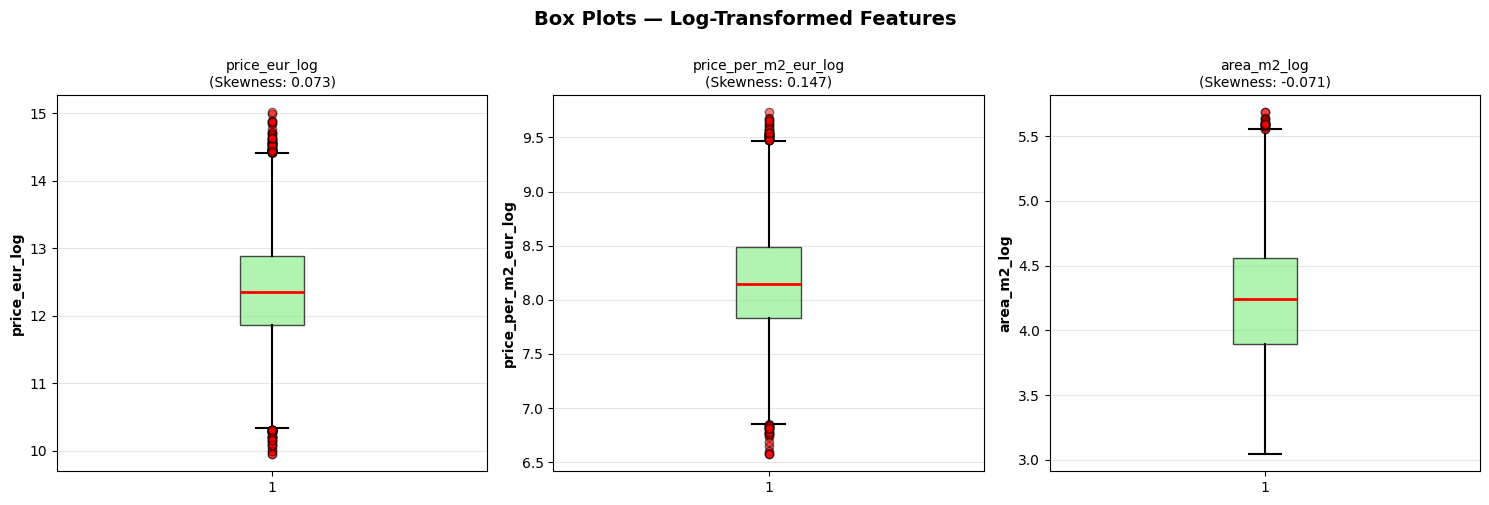

In [102]:
# Create box plots for the three log-transformed columns
log_cols = ['price_eur_log', 'price_per_m2_eur_log', 'area_m2_log']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()

for idx, col in enumerate(log_cols):
    ax = axes[idx]
    
    # Box plot
    bp = ax.boxplot(df_sales_log[col].dropna(), vert=True, patch_artist=True,
                     boxprops=dict(facecolor='lightgreen', alpha=0.7),
                     whiskerprops=dict(color='black', linewidth=1.5),
                     capprops=dict(color='black', linewidth=1.5),
                     medianprops=dict(color='red', linewidth=2),
                     flierprops=dict(marker='o', markerfacecolor='red', markersize=6, alpha=0.5))
    
    ax.set_ylabel(col, fontsize=10, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f'{col}\n(Skewness: {df_sales_log[col].skew():.3f})', fontsize=10)

plt.suptitle('Box Plots — Log-Transformed Features', fontsize=14, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('09_boxplots_log_transformed.png', dpi=300, bbox_inches='tight')
plt.show()

## Sales Eras & Floor & USD final df: df_sales_clean 

In [103]:
def year_to_era(year):
    if pd.isna(year):
        return 'unknown'
    elif year < 1949:
        return 'altbau_pre_1949'
    elif 1949 <= year < 1990:
        return 'post_war_1949_1990'
    elif 1990 <= year < 2010:
        return 'modern_1990_2010'
    else:
        return 'new_post_2010'

df_sales_log['building_era'] = df_sales_log['year_built'].apply(year_to_era)

In [104]:
# Top floor & Ground floor
df_sales_log['is_top_floor'] = (df_sales_log['floor'] == df_sales_log['total_floors']).astype(int)
df_sales_log['is_ground_floor'] = (df_sales_log['floor'] == 0).astype(int)

In [105]:
df_sales_log.head()

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing,price_eur_log,price_per_m2_eur_log,area_m2_log,is_top_floor,is_ground_floor
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.5,13.265599,9.031094,4.248495,0,0
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.3,12.842652,8.435115,4.418841,0,0
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.1,11.018646,7.677400,3.377588,0,0
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.5,13.474429,8.792246,4.691348,0,0
4,S000005,2021-05-10,Wittenau,Reinickendorf,low,52.59374,13.31938,2_room,2,44.7,4,4,1884,altbau_pre_1949,E,seitenflügel,renovierungsbedürftig,False,False,True,False,Rosa-Luxemburg-Platz,U2,39,tram_bus,9.47,71000,1597,77078,1725,1.1,11.170449,7.376508,3.822098,1,0


In [109]:
# One-hot encode: era, height energy_class, position, condition

era_dummies = pd.get_dummies(df_sales_log['building_era'], prefix='building_era', drop_first=True)

df_sales_log = pd.concat([df_sales_log, era_dummies, height_dummies], axis=1)

# One-hot encode: energy_class, position, condition
energy_dummies = pd.get_dummies(df_sales_log['energy_class'], prefix='energy_class', drop_first=True)
position_dummies = pd.get_dummies(df_sales_log['position'], prefix='position', drop_first=True)
condition_dummies = pd.get_dummies(df_sales_log['condition'], prefix='condition', drop_first=True)

# Concatenate to dataframe
df_sales_log = pd.concat([df_sales_log, energy_dummies, position_dummies, condition_dummies], axis=1)

print(f"  New shape: {df_sales_log.shape}")
print(f"\nNew columns created:")
print(f"  Energy class: {energy_dummies.columns.tolist()}")
print(f"  Position: {position_dummies.columns.tolist()}")
print(f"  Condition: {condition_dummies.columns.tolist()}")




  New shape: (50000, 96)

New columns created:
  Energy class: ['energy_class_A_plus', 'energy_class_B', 'energy_class_C', 'energy_class_D', 'energy_class_E', 'energy_class_F', 'energy_class_G', 'energy_class_H']
  Position: ['position_hinterhaus', 'position_seitenflügel', 'position_vorderhaus']
  Condition: ['condition_modernisiert', 'condition_renoviert', 'condition_renovierungsbedürftig', 'condition_saniert']


In [110]:
df_sales_log.head()

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,price_usd,price_per_m2_usd,mortgage_rate_at_listing,price_eur_log,price_per_m2_eur_log,area_m2_log,is_top_floor,is_ground_floor,building_era_modern_1990_2010,building_era_new_post_2010,building_era_post_war_1949_1990,building_height_low_rise,building_height_mid_rise,energy_class_A_plus,energy_class_B,energy_class_C,energy_class_D,energy_class_E,energy_class_F,energy_class_G,energy_class_H,position_hinterhaus,position_seitenflügel,position_vorderhaus,condition_modernisiert,condition_renoviert,condition_renovierungsbedürftig,condition_saniert,building_era_modern_1990_2010,building_era_new_post_2010,building_era_post_war_1949_1990,building_height_low_rise,building_height_mid_rise,energy_class_A_plus,energy_class_B,energy_class_C,energy_class_D,energy_class_E,energy_class_F,energy_class_G,energy_class_H,position_hinterhaus,position_seitenflügel,position_vorderhaus,condition_modernisiert,condition_renoviert,condition_renovierungsbedürftig,condition_saniert,building_era_modern_1990_2010,building_era_new_post_2010,building_era_post_war_1949_1990,building_height_low_rise,building_height_mid_rise,energy_class_A_plus,energy_class_B,energy_class_C,energy_class_D,energy_class_E,energy_class_F,energy_class_G,energy_class_H,position_hinterhaus,position_seitenflügel,position_vorderhaus,condition_modernisiert,condition_renoviert,condition_renovierungsbedürftig,condition_saniert
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,622867,9026,3.5,13.265599,9.031094,4.248495,0,0,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,408004,4973,3.3,12.842652,8.435115,4.418841,0,0,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,65916,2331,1.1,11.018646,7.677400,3.377588,0,0,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,767527,7109,3.5,13.474429,8.792246,4.691348,0,0,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,Tru

In [111]:
usd_cols = [col for col in df_sales_log.columns if 'usd' in col.lower()]
if usd_cols:
    df_sales_log = df_sales_log.drop(columns=usd_cols)
    print(f"\n✓ Dropped USD columns: {usd_cols}")


✓ Dropped USD columns: ['price_usd', 'price_per_m2_usd']


In [113]:
df_sales_clean = df_sales_log

In [114]:
df_sales_clean 

,id,date_listed,ortsteil,bezirk,kiez_premium,lat,lon,property_type,rooms,area_m2,floor,total_floors,year_built,building_era,energy_class,position,condition,has_lift,has_balcony,has_cellar,has_parking,transit_station,transit_line,transit_distance_min,transit_distance_type,to_brandenburg_gate_km,price_eur,price_per_m2_eur,mortgage_rate_at_listing,price_eur_log,price_per_m2_eur_log,area_m2_log,is_top_floor,is_ground_floor,building_era_modern_1990_2010,building_era_new_post_2010,building_era_post_war_1949_1990,building_height_low_rise,building_height_mid_rise,energy_class_A_plus,energy_class_B,energy_class_C,energy_class_D,energy_class_E,energy_class_F,energy_class_G,energy_class_H,position_hinterhaus,position_seitenflügel,position_vorderhaus,condition_modernisiert,condition_renoviert,condition_renovierungsbedürftig,condition_saniert,building_era_modern_1990_2010,building_era_new_post_2010,building_era_post_war_1949_1990,building_height_low_rise,building_height_mid_rise,energy_class_A_plus,energy_class_B,energy_class_C,energy_class_D,energy_class_E,energy_class_F,energy_class_G,energy_class_H,position_hinterhaus,position_seitenflügel,position_vorderhaus,condition_modernisiert,condition_renoviert,condition_renovierungsbedürftig,condition_saniert,building_era_modern_1990_2010,building_era_new_post_2010,building_era_post_war_1949_1990,building_height_low_rise,building_height_mid_rise,energy_class_A_plus,energy_class_B,energy_class_C,energy_class_D,energy_class_E,energy_class_F,energy_class_G,energy_class_H,position_hinterhaus,position_seitenflügel,position_vorderhaus,condition_modernisiert,condition_renoviert,condition_renovierungsbedürftig,condition_saniert
0,S000001,2024-11-23,Kreuzberg,Friedrichshain-Kreuzberg,high,52.50656,13.40768,2_room,2,69.0,1,6,2011,new_post_2010,B,hinterhaus,saniert,True,True,False,False,Gleisdreieck,U1,10,tram_bus,2.30,577000,8358,3.50,13.265599,9.031094,4.248495,0,0,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True
1,S000002,2025-06-06,Gatow,Spandau,medium,52.47856,13.17688,3_room,3,82.0,4,5,2016,new_post_2010,B,vorderhaus,modernisiert,True,True,True,False,Wilmersdorfer Straße,U7,44,tram_bus,14.23,378000,4605,3.30,12.842652,8.435115,4.418841,0,0,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False,False,True,False,False,True,False,True,False,False,False,False,False,False,False,False,True,True,False,False,False
2,S000003,2021-03-13,Köpenick (Ort),Treptow-Köpenick,medium,52.45023,13.57624,1_room,1,28.3,2,4,1976,post_war_1949_1990,G,hinterhaus,modernisiert,False,False,True,True,Altstadt Spandau,U7,116,tram_bus,15.32,61000,2158,1.10,11.018646,7.677400,3.377588,0,0,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False,False,True,False,False,False
3,S000004,2024-12-08,Mitte (Ort),Mitte,high,52.52427,13.41293,4_room,4,108.0,3,5,1950,post_war_1949_1990,C,seitenflügel,modernisiert,False,False,True,False,Prinzenstraße,U1,11,tram_bus,2.54,711000,6582,3.50,13.474429,8.792246,4.691348,0,0,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,True,False,False,True,False,False,False,False,False,False,True

## Final DF

In [118]:
df_sales_clean.to_csv('/Users/lukasstraehnz/code/MarieKatha/berlin-property-intelligence/raw_data/df_sales_clean.csv', index=False)